# Figure 3: functional representation of perturbation responses

Final figure-generation blocks for functional-program similarity, the erlotinib/H1975 signature-to-score example, and resource storage comparison.

In [ ]:

from pathlib import Path
import json
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

sns.set_theme(style="white", context="paper")

# Keep PDF text Illustrator-editable instead of Type 3 outlines.
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"] = "Arial"

TASK_DIR = Path('/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-148_pxfquery_new_figure3_concept_and_notebook_workbe')
TABLE_DIR = TASK_DIR / '4_artifact/5_table'
FIG_DIR = TASK_DIR / '4_artifact/4_picture'
TMP_DIR = TASK_DIR / '4_artifact/1_tmp'
for d in [TABLE_DIR, FIG_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

GMT_CANDIDATES = [
    Path('/Users/dudu/Documents/3_Project/8_functional_query/90_archive/20260429_pre_restructure/0_materials/3_work/input/genesets/merged.gmt'),
    Path('/Users/dudu/Documents/3_Project/8_functional_query/90_archive/20260429_pre_restructure/1_claude/workspace/input/genesets/merged.gmt'),
]
GMT_PATH = next((p for p in GMT_CANDIDATES if p.exists()), None)
assert GMT_PATH is not None, 'No merged.gmt candidate exists on this machine.'
GMT_PATH



In [ ]:

def parse_merged_gmt(path: Path):
    records = []
    gene_sets = {}
    with path.open() as f:
        for line_no, line in enumerate(f, start=1):
            parts = line.rstrip('\n').split('\t')
            if not parts or not parts[0]:
                continue
            name = parts[0].strip()
            # Hallmark rows have a URL/description field. MP rows in this merged.gmt start with genes directly.
            if len(parts) > 1 and (parts[1].startswith('http://') or parts[1].startswith('https://')):
                description = parts[1]
                genes = parts[2:]
            else:
                description = ''
                genes = parts[1:]
            genes = sorted({g.strip().upper() for g in genes if g and g.strip()})
            if name.startswith('HALLMARK_'):
                collection = 'Hallmark'
            elif name.startswith('MP'):
                collection = 'MPS'
            else:
                collection = 'Other'
            gene_sets[name] = set(genes)
            for gene in genes:
                records.append({
                    'collection': collection,
                    'gene_set': name,
                    'gene': gene,
                    'source_gmt': str(path),
                    'line_no': line_no,
                    'description': description,
                })
    return gene_sets, pd.DataFrame(records)

gene_sets_all, membership = parse_merged_gmt(GMT_PATH)
summary = membership.groupby('collection').agg(n_gene_sets=('gene_set', 'nunique'), n_membership_rows=('gene', 'size'), n_unique_genes=('gene', 'nunique')).reset_index()
summary


In [ ]:

hallmark_membership = membership[membership['collection'] == 'Hallmark'].copy()
mps_membership = membership[membership['collection'] == 'MPS'].copy()
assert hallmark_membership['gene_set'].nunique() == 50, hallmark_membership['gene_set'].nunique()
assert mps_membership['gene_set'].nunique() == 41, mps_membership['gene_set'].nunique()

hallmark_membership[['gene_set', 'gene', 'description', 'source_gmt', 'line_no']].to_csv(TABLE_DIR / 'table_hallmark_gene_sets.csv', index=False)
mps_membership[['gene_set', 'gene', 'description', 'source_gmt', 'line_no']].to_csv(TABLE_DIR / 'table_mps_gene_sets.csv', index=False)
summary.to_csv(TABLE_DIR / 'table_gene_set_collection_summary.csv', index=False)
summary


In [ ]:

def jaccard_pairwise(gene_sets: dict[str, set[str]], names: list[str], collection: str):
    n = len(names)
    idx = np.eye(n)
    dist = np.zeros((n, n), dtype=float)
    rows = []
    for i, a in enumerate(names):
        ga = gene_sets[a]
        for j, b in enumerate(names):
            gb = gene_sets[b]
            inter = len(ga & gb)
            union = len(ga | gb)
            jac = inter / union if union else np.nan
            idx[i, j] = jac
            dist[i, j] = 1.0 - jac if not np.isnan(jac) else np.nan
            if i < j:
                shared = sorted(ga & gb)
                rows.append({
                    'collection': collection,
                    'gene_set_a': a,
                    'gene_set_b': b,
                    'n_intersection': inter,
                    'n_union': union,
                    'jaccard_index': jac,
                    'jaccard_distance': 1.0 - jac if not np.isnan(jac) else np.nan,
                    'shared_genes_preview': ';'.join(shared[:20]),
                })
    return pd.DataFrame(idx, index=names, columns=names), pd.DataFrame(dist, index=names, columns=names), pd.DataFrame(rows)

hallmark_names = sorted(hallmark_membership['gene_set'].unique())
mps_names = sorted(mps_membership['gene_set'].unique(), key=lambda x: int(x.split()[0].replace('MP','')) if x.split()[0].replace('MP','').isdigit() else x)

hallmark_j, hallmark_d, hallmark_pairs = jaccard_pairwise(gene_sets_all, hallmark_names, 'Hallmark')
mps_j, mps_d, mps_pairs = jaccard_pairwise(gene_sets_all, mps_names, 'MPS')

hallmark_d.to_csv(TABLE_DIR / 'matrix_hallmark_jaccard_distance.tsv', sep='\t')
mps_d.to_csv(TABLE_DIR / 'matrix_mps_jaccard_distance.tsv', sep='\t')
pairwise_summary = pd.concat([hallmark_pairs, mps_pairs], ignore_index=True)
pairwise_summary.to_csv(TABLE_DIR / 'table_pairwise_jaccard_summary.csv', index=False)
pairwise_summary.head()


In [ ]:

size_summary = membership.groupby(['collection', 'gene_set']).agg(n_genes=('gene', 'nunique')).reset_index()
size_summary.to_csv(TABLE_DIR / 'table_gene_set_size_summary.csv', index=False)

close_pairs = pairwise_summary.sort_values(['collection', 'jaccard_distance']).groupby('collection').head(8).assign(pair_type='close')
far_pairs = pairwise_summary.sort_values(['collection', 'jaccard_distance'], ascending=[True, False]).groupby('collection').head(8).assign(pair_type='far')
representative_pairs = pd.concat([close_pairs, far_pairs], ignore_index=True)[[
    'collection', 'pair_type', 'gene_set_a', 'gene_set_b', 'n_intersection', 'n_union',
    'jaccard_index', 'jaccard_distance', 'shared_genes_preview'
]]
representative_pairs.to_csv(TABLE_DIR / 'table_representative_gene_set_pairs.csv', index=False)
size_summary.groupby('collection')['n_genes'].describe(), representative_pairs.head(10)


In [ ]:

def clustered_order(distance_df: pd.DataFrame):
    values = distance_df.values.astype(float)
    values = np.nan_to_num(values, nan=1.0)
    if len(distance_df) <= 2:
        return list(distance_df.index)
    condensed = squareform(values, checks=False)
    Z = linkage(condensed, method='average')
    return [distance_df.index[i] for i in leaves_list(Z)]

hallmark_order = clustered_order(hallmark_d)
mps_order = clustered_order(mps_d)

pd.DataFrame({'rank': range(1, len(hallmark_order)+1), 'gene_set': hallmark_order}).to_csv(TABLE_DIR / 'table_hallmark_cluster_order.csv', index=False)
pd.DataFrame({'rank': range(1, len(mps_order)+1), 'gene_set': mps_order}).to_csv(TABLE_DIR / 'table_mps_cluster_order.csv', index=False)

len(hallmark_order), len(mps_order)


In [ ]:

def short_label(name: str, max_len=28):
    if name.startswith('HALLMARK_'):
        name = name.replace('HALLMARK_', '').replace('_', ' ').title()
    return name if len(name) <= max_len else name[:max_len-1] + '…'

def savefig_all(fig, stem: str):
    for ext in ['pdf', 'svg', 'png']:
        fig.savefig(FIG_DIR / f'{stem}.{ext}', bbox_inches='tight', dpi=300)

# A/B heatmaps
for collection, dist_df, order, stem, title in [
    ('Hallmark', hallmark_d, hallmark_order, 'figure3_panelA_hallmark_jaccard_heatmap', 'Hallmark gene-set Jaccard distance'),
    ('MPS', mps_d, mps_order, 'figure3_panelB_mps_jaccard_heatmap', 'MPS gene-set Jaccard distance'),
]:
    ordered = dist_df.loc[order, order]
    fig_w = 7.5 if collection == 'Hallmark' else 7.0
    fig_h = 6.8 if collection == 'Hallmark' else 6.3
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(
        ordered, ax=ax, cmap='viridis', vmin=0, vmax=1, square=True,
        cbar_kws={'label': 'Jaccard distance (1 - overlap/union)', 'shrink': 0.75},
        xticklabels=[short_label(x, 18) for x in ordered.columns],
        yticklabels=[short_label(x, 18) for x in ordered.index],
        linewidths=0.0,
    )
    ax.set_title(title, fontsize=12, pad=10)
    ax.tick_params(axis='x', labelrotation=90, labelsize=5.5)
    ax.tick_params(axis='y', labelsize=5.5)
    ax.set_xlabel('')
    ax.set_ylabel('')
    savefig_all(fig, stem)
    plt.close(fig)


In [ ]:

# C. gene-set size distribution
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), gridspec_kw={'width_ratios': [1, 1.25]})
sns.boxplot(data=size_summary, x='collection', y='n_genes', ax=axes[0], palette=['#4C78A8', '#F58518'])
sns.stripplot(data=size_summary, x='collection', y='n_genes', ax=axes[0], color='black', alpha=0.45, size=3)
axes[0].set_title('Gene-set size')
axes[0].set_xlabel('')
axes[0].set_ylabel('Genes per set')

sns.histplot(data=size_summary, x='n_genes', hue='collection', bins=18, kde=True, ax=axes[1], palette=['#4C78A8', '#F58518'], element='step')
axes[1].set_title('Size distribution')
axes[1].set_xlabel('Genes per set')
axes[1].set_ylabel('Count')
fig.suptitle('Hallmark and MPS gene-set size distributions', y=1.04, fontsize=12)
savefig_all(fig, 'figure3_panelC_gene_set_size_distribution')
plt.close(fig)

# D. pairwise distance distribution
fig, ax = plt.subplots(figsize=(6.8, 3.4))
sns.histplot(data=pairwise_summary, x='jaccard_distance', hue='collection', bins=30, kde=True, element='step', palette=['#4C78A8', '#F58518'], ax=ax)
ax.set_title('Pairwise Jaccard distance distribution')
ax.set_xlabel('Jaccard distance')
ax.set_ylabel('Gene-set pairs')
ax.set_xlim(0, 1)
savefig_all(fig, 'figure3_panelD_pairwise_distance_distribution')
plt.close(fig)


In [ ]:

# E. representative close/far pairs as a compact table figure
rep_plot = representative_pairs.copy()
rep_plot['pair_label'] = rep_plot['gene_set_a'].map(lambda x: short_label(x, 32)) + '  vs  ' + rep_plot['gene_set_b'].map(lambda x: short_label(x, 32))
rep_plot = rep_plot.sort_values(['collection', 'pair_type', 'jaccard_distance'], ascending=[True, True, True])

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True)
for ax, collection in zip(axes, ['Hallmark', 'MPS']):
    sub = rep_plot[rep_plot['collection'] == collection].copy()
    sub['label'] = sub['pair_type'].str.title() + ': ' + sub['pair_label']
    sub = sub.sort_values(['pair_type', 'jaccard_distance'], ascending=[True, True])
    colors = sub['pair_type'].map({'close': '#2A9D8F', 'far': '#E76F51'})
    ax.barh(range(len(sub)), sub['jaccard_distance'], color=colors)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['label'], fontsize=6.5)
    ax.invert_yaxis()
    ax.set_title(f'{collection}: representative pairs')
    ax.set_xlabel('Jaccard distance')
    ax.set_xlim(0, 1)
fig.tight_layout()
savefig_all(fig, 'figure3_panelE_representative_pairs')
plt.close(fig)


In [ ]:
# FIGURE3A_JACCARD_KDE_CELL
# Main Figure 3A draft: three vertically stacked KDE distributions of Jaccard similarity.
# The heatmap triptych remains available as an appendix-style structural view.
kde_rows = []
for label, df in [
    ('Hallmark-Hallmark', hallmark_pairs),
    ('MPS-MPS', mps_pairs),
]:
    vals = df['jaccard_index'].dropna().astype(float).to_numpy()
    kde_rows.extend({'comparison': label, 'jaccard_similarity': v} for v in vals)

# Cross-collection pair values are computed here so Figure 3A is self-contained.
cross_for_kde = []
for h in hallmark_order:
    gh = gene_sets_all[h]
    for m in mps_order:
        gm = gene_sets_all[m]
        union = gh | gm
        jac = len(gh & gm) / len(union) if union else np.nan
        cross_for_kde.append(jac)
kde_rows.extend({'comparison': 'Hallmark-MPS', 'jaccard_similarity': v} for v in cross_for_kde if not np.isnan(v))

kde_df = pd.DataFrame(kde_rows)
order = ['Hallmark-Hallmark', 'MPS-MPS', 'Hallmark-MPS']
kde_summary = (
    kde_df.groupby('comparison')['jaccard_similarity']
    .agg(n_pairs='size', median='median', mean='mean', p95=lambda s: s.quantile(0.95), max='max')
    .reindex(order)
    .reset_index()
)
kde_df.to_csv(TABLE_DIR / 'table_figure3a_jaccard_kde_values.csv', index=False)
kde_summary.to_csv(TABLE_DIR / 'table_figure3a_jaccard_kde_summary.csv', index=False)

palette = {
    'Hallmark-Hallmark': '#2f6f9e',
    'MPS-MPS': '#7a5aa6',
    'Hallmark-MPS': '#2f8f6f',
}

fig, axes = plt.subplots(3, 1, figsize=(5.2, 4.8), dpi=300, sharex=True, constrained_layout=True)
for ax, label in zip(axes, order):
    vals = kde_df.loc[kde_df['comparison'] == label, 'jaccard_similarity'].to_numpy()
    median = float(np.median(vals))
    p95 = float(np.quantile(vals, 0.95))
    color = palette[label]
    sns.kdeplot(
        x=vals,
        ax=ax,
        color=color,
        fill=True,
        alpha=0.24,
        linewidth=1.4,
        bw_adjust=0.75,
        clip=(0, 1),
        cut=0,
    )
    ax.axvline(median, color=color, linestyle='--', linewidth=1.0)
    ax.text(
        0.985,
        0.82,
        f'median {median:.3f}\np95 {p95:.3f}',
        transform=ax.transAxes,
        color=color,
        fontsize=7.5,
        ha='right',
        va='top',
    )
    ax.text(
        0.015,
        0.82,
        label,
        transform=ax.transAxes,
        color='#222222',
        fontsize=8.5,
        ha='left',
        va='top',
    )
    ax.set_ylabel('Density', fontsize=8)
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8, length=2)

axes[-1].set_xlabel('Jaccard similarity', fontsize=9)
fig.suptitle('Figure 3A: pairwise gene-set overlap distributions', fontsize=10.5, y=1.02)
for ext in ['pdf', 'svg', 'png']:
    fig.savefig(FIG_DIR / f'figure3_panelA_jaccard_similarity_kde.{ext}', bbox_inches='tight')
plt.show()

kde_summary


## Erlotinib/H1975 functional-score example and resource compression

In [ ]:
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import FancyArrowPatch, Rectangle

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False

TASK_DIR = Path('/Users/dudu/Documents/3_Project/12_PxFquery/5_phase_translation/G-011_paper_figure_planning/T-148_pxfquery_new_figure3_concept_and_notebook_workbe')
TABLE_DIR = TASK_DIR / '4_artifact/5_table'
MATERIAL_DIR = TABLE_DIR / 'figure3b_raw_material'
FIG_DIR = TASK_DIR / '4_artifact/4_picture'
TMP_DIR = TASK_DIR / '4_artifact/1_tmp'
for d in [TABLE_DIR, MATERIAL_DIR, FIG_DIR, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)


In [ ]:
raw = pd.read_csv(MATERIAL_DIR / 'erlotinib_h1975_raw_gene_signature.csv')
func = pd.read_csv(MATERIAL_DIR / 'erlotinib_h1975_pxfquery_functional_score_vector.csv')
raw_meta = json.loads((MATERIAL_DIR / 'erlotinib_h1975_raw_gene_signature_meta.json').read_text())
func_meta = json.loads((MATERIAL_DIR / 'erlotinib_h1975_pxfquery_functional_score_vector_meta.json').read_text())

# Fixed random permutation for the raw gene signature strip. This is a display order only;
# it emphasizes that the gene-level vector is high-dimensional and not directly human-readable.
rng = np.random.default_rng(20260630)
raw_ordered = raw.iloc[rng.permutation(len(raw))].reset_index(drop=True)
func_ordered = func.copy()

pos_terms = func.sort_values('functional_score', ascending=False).head(5)
neg_terms = func.sort_values('functional_score').head(5)
summary = {
    'case': 'erlotinib in H1975',
    'sig_id': raw_meta['sig_id'],
    'raw_gene_features': int(raw.shape[0]),
    'functional_axes': int(func.shape[0]),
    'top_activated': pos_terms[['function','functional_score']].to_dict('records'),
    'top_suppressed': neg_terms[['function','functional_score']].to_dict('records'),
}
(Path(MATERIAL_DIR) / 'figure3b_erlotinib_h1975_case_summary.json').write_text(json.dumps(summary, indent=2))
summary




In [ ]:
# Figure 3B: real example of representation conversion.
raw_values = raw_ordered['raw_signature_score'].to_numpy()[None, :]
func_values = func_ordered['functional_score'].to_numpy()[None, :]

fig = plt.figure(figsize=(9.2, 3.05), dpi=300)
fig.text(0.04, 0.94, 'Figure 3B. From gene-level perturbation signature to functional language', fontsize=10.2, weight='bold', ha='left', va='top')
fig.text(0.04, 0.87, 'Example: erlotinib treatment in H1975 cells', fontsize=8.2, ha='left', va='top', color='#333333')

ax_raw = fig.add_axes([0.045, 0.49, 0.41, 0.16])
ax_func = fig.add_axes([0.545, 0.49, 0.13, 0.16])
ax_text = fig.add_axes([0.765, 0.32, 0.21, 0.42])

raw_norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
func_norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
raw_im = ax_raw.imshow(raw_values, aspect='auto', cmap='RdBu_r', norm=raw_norm, interpolation='nearest')
func_im = ax_func.imshow(func_values, aspect='auto', cmap='RdBu_r', norm=func_norm, interpolation='nearest')

for ax in [ax_raw, ax_func]:
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.45)
        spine.set_color('#333333')

ax_raw.set_title('CMAP gene-level signature', fontsize=8.2, pad=5)
ax_func.set_title('PxFquery functional score', fontsize=8.2, pad=5)
fig.text(0.250, 0.415, f'{raw.shape[0]:,} gene features, shuffled display order', fontsize=7.2, ha='center', va='top')
fig.text(0.610, 0.415, '91 Hallmark/MPS axes', fontsize=7.4, ha='center', va='top')
fig.text(0.610, 0.374, 'score = NES x -log10(FDR)', fontsize=6.7, ha='center', va='top', color='#333333')

# Arrows and labels.
fig.add_artist(FancyArrowPatch((0.468, 0.575), (0.532, 0.575), transform=fig.transFigure, arrowstyle='-|>', mutation_scale=10, linewidth=0.9, color='#333333'))
fig.add_artist(FancyArrowPatch((0.690, 0.575), (0.752, 0.575), transform=fig.transFigure, arrowstyle='-|>', mutation_scale=10, linewidth=0.9, color='#333333'))
fig.text(0.500, 0.625, 'GSEA projection', fontsize=7.0, ha='center', va='bottom')
fig.text(0.721, 0.625, 'LLM summary', fontsize=7.0, ha='center', va='bottom')

# Compact colorbars.
cax1 = fig.add_axes([0.045, 0.31, 0.41, 0.035])
cb1 = fig.colorbar(raw_im, cax=cax1, orientation='horizontal')
cb1.set_label('gene signature score', fontsize=6.5, labelpad=1)
cb1.ax.tick_params(labelsize=6, length=2)
cax2 = fig.add_axes([0.545, 0.31, 0.13, 0.035])
cb2 = fig.colorbar(func_im, cax=cax2, orientation='horizontal')
cb2.set_label('functional score', fontsize=6.5, labelpad=1)
cb2.ax.tick_params(labelsize=6, length=2)

# Natural-language panel from the real top positive/negative functional scores.
ax_text.axis('off')
ax_text.add_patch(Rectangle((0, 0), 1, 1, transform=ax_text.transAxes, facecolor='#f8f8f8', edgecolor='#333333', linewidth=0.5))
ax_text.text(0.06, 0.90, 'Natural-language interpretation', fontsize=8.1, weight='bold', ha='left', va='top')
ax_text.text(
    0.06, 0.72,
    'Erlotinib induces stress-associated\nprograms in H1975 cells, including\nROS, p53 and unfolded-protein\nresponse axes.',
    fontsize=6.6, ha='left', va='top', linespacing=1.18,
)
ax_text.text(
    0.06, 0.37,
    'The same functional score vector\nshows strong suppression of\nproliferative cell-cycle programs:\nE2F targets, G2/M and G1/S.',
    fontsize=6.6, ha='left', va='top', linespacing=1.18,
)

for ext in ['pdf', 'svg', 'png']:
    fig.savefig(FIG_DIR / f'figure3_panelB_signature_to_language.{ext}', bbox_inches='tight')
plt.show()






In [ ]:
# Figure 3C: storage reduction from raw CMAP GCTX to PxFquery functional-score NPZ.
storage = pd.DataFrame([
    {'modality': 'Compound', 'source': 'CMAP level-5 GCTX', 'bytes': 35518405386, 'label': '34G'},
    {'modality': 'shRNA', 'source': 'CMAP level-5 GCTX', 'bytes': 11754477623, 'label': '11G'},
    {'modality': 'CRISPR', 'source': 'CMAP level-5 GCTX', 'bytes': 6516812529, 'label': '6.1G'},
    {'modality': 'Compound', 'source': 'PxFquery score NPZ', 'bytes': 24158097, 'label': '23 MB'},
    {'modality': 'shRNA', 'source': 'PxFquery score NPZ', 'bytes': 23082570, 'label': '22 MB'},
    {'modality': 'CRISPR', 'source': 'PxFquery score NPZ', 'bytes': 15863651, 'label': '15 MB'},
])
storage['MiB'] = storage['bytes'] / 1024 / 1024
storage.to_csv(TABLE_DIR / 'table_figure3c_storage_comparison.csv', index=False)

modalities = ['Compound', 'shRNA', 'CRISPR']
x = np.arange(len(modalities))
width = 0.34
raw_vals = storage[storage['source'] == 'CMAP level-5 GCTX'].set_index('modality').loc[modalities]
pxf_vals = storage[storage['source'] == 'PxFquery score NPZ'].set_index('modality').loc[modalities]

fig, ax = plt.subplots(figsize=(6.6, 3.2), dpi=300, constrained_layout=True)
b1 = ax.bar(x - width/2, raw_vals['MiB'], width, label='CMAP level-5 GCTX', color='#8a8a8a', edgecolor='#333333', linewidth=0.4)
b2 = ax.bar(x + width/2, pxf_vals['MiB'], width, label='PxFquery score NPZ', color='#3b7ddd', edgecolor='#1f3f6f', linewidth=0.4)
ax.set_yscale('log')
ax.set_ylabel('Storage size (MiB, log scale)', fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(modalities, fontsize=8)
ax.tick_params(axis='y', labelsize=7)
ax.legend(frameon=False, fontsize=7.5, loc='upper right')
ax.set_title('Figure 3C. Compact functional-score matrices reduce resource size', fontsize=9.5, loc='left', pad=8)
ax.grid(axis='y', which='major', linestyle=':', linewidth=0.45, color='#bbbbbb')
ax.set_axisbelow(True)
for bars, labels in [(b1, raw_vals['label']), (b2, pxf_vals['label'])]:
    for bar, label in zip(bars, labels):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.12, label, ha='center', va='bottom', fontsize=7)

for i, modality in enumerate(modalities):
    ratio = raw_vals.loc[modality, 'bytes'] / pxf_vals.loc[modality, 'bytes']
    ax.text(
        x[i],
        55,
        f'{ratio:,.0f}x smaller',
        ha='center',
        va='bottom',
        fontsize=8,
        color='#1f3f6f',
        weight='bold',
    )
for ext in ['pdf', 'svg', 'png']:
    fig.savefig(FIG_DIR / f'figure3_panelC_storage_comparison.{ext}', bbox_inches='tight')
plt.show()
storage




## Executed panel blocks from the original Figure 3 notebooks

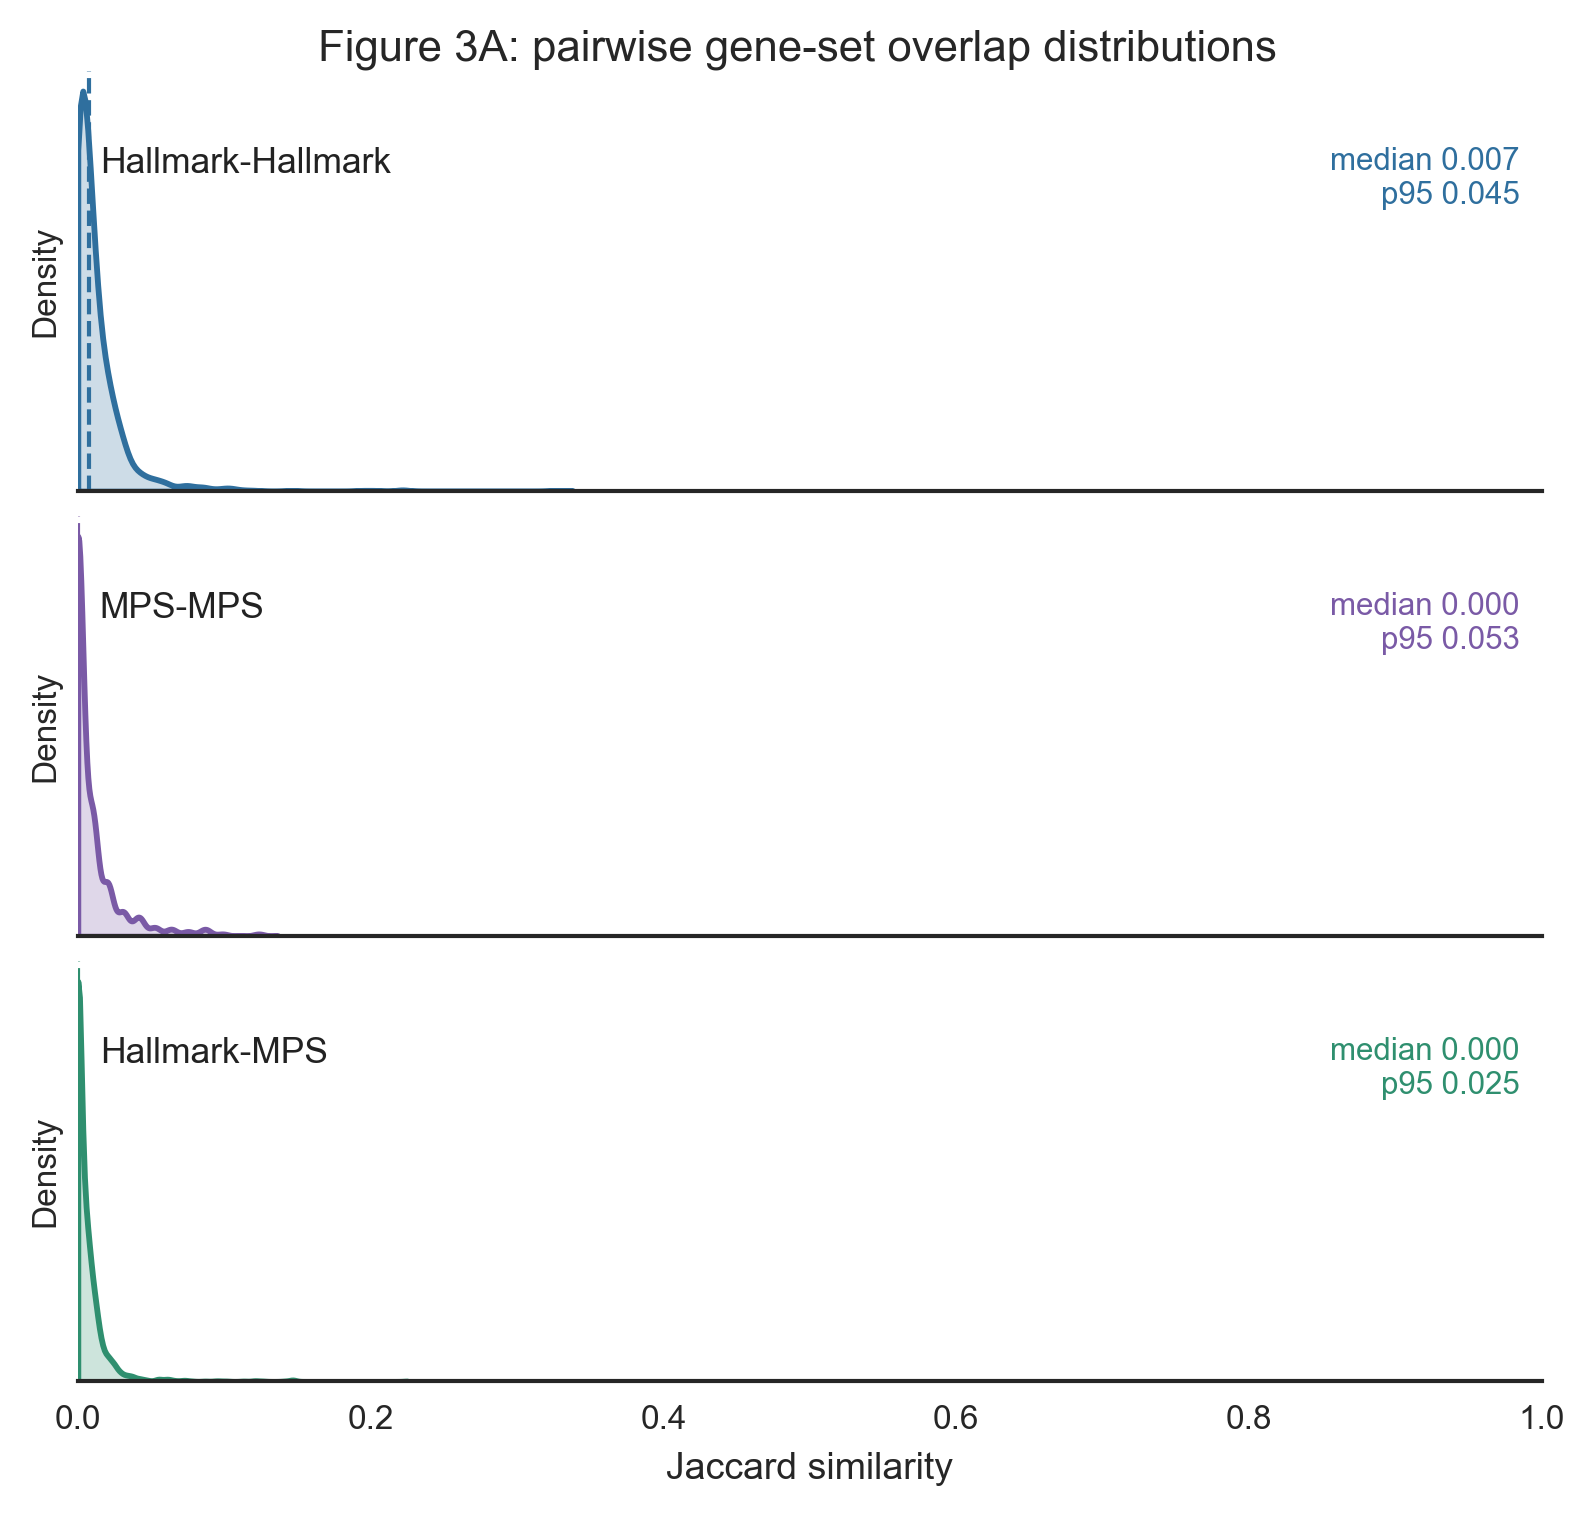

,comparison,n_pairs,median,mean,p95,max
0,Hallmark-Hallmark,1225,0.007353,0.013353,0.045319,0.337793
1,MPS-MPS,820,0.000000,0.009819,0.052632,0.136364
2,Hallmark-MPS,2050,0.000000,0.006480,0.024590,0.225000


In [12]:
# FIGURE3A_JACCARD_KDE_CELL
# Main Figure 3A draft: three vertically stacked KDE distributions of Jaccard similarity.
# The heatmap triptych remains available as an appendix-style structural view.
kde_rows = []
for label, df in [
    ('Hallmark-Hallmark', hallmark_pairs),
    ('MPS-MPS', mps_pairs),
]:
    vals = df['jaccard_index'].dropna().astype(float).to_numpy()
    kde_rows.extend({'comparison': label, 'jaccard_similarity': v} for v in vals)

# Cross-collection pair values are computed here so Figure 3A is self-contained.
cross_for_kde = []
for h in hallmark_order:
    gh = gene_sets_all[h]
    for m in mps_order:
        gm = gene_sets_all[m]
        union = gh | gm
        jac = len(gh & gm) / len(union) if union else np.nan
        cross_for_kde.append(jac)
kde_rows.extend({'comparison': 'Hallmark-MPS', 'jaccard_similarity': v} for v in cross_for_kde if not np.isnan(v))

kde_df = pd.DataFrame(kde_rows)
order = ['Hallmark-Hallmark', 'MPS-MPS', 'Hallmark-MPS']
kde_summary = (
    kde_df.groupby('comparison')['jaccard_similarity']
    .agg(n_pairs='size', median='median', mean='mean', p95=lambda s: s.quantile(0.95), max='max')
    .reindex(order)
    .reset_index()
)
kde_df.to_csv(TABLE_DIR / 'table_figure3a_jaccard_kde_values.csv', index=False)
kde_summary.to_csv(TABLE_DIR / 'table_figure3a_jaccard_kde_summary.csv', index=False)

palette = {
    'Hallmark-Hallmark': '#2f6f9e',
    'MPS-MPS': '#7a5aa6',
    'Hallmark-MPS': '#2f8f6f',
}

fig, axes = plt.subplots(3, 1, figsize=(5.2, 4.8), dpi=300, sharex=True, constrained_layout=True)
for ax, label in zip(axes, order):
    vals = kde_df.loc[kde_df['comparison'] == label, 'jaccard_similarity'].to_numpy()
    median = float(np.median(vals))
    p95 = float(np.quantile(vals, 0.95))
    color = palette[label]
    sns.kdeplot(
        x=vals,
        ax=ax,
        color=color,
        fill=True,
        alpha=0.24,
        linewidth=1.4,
        bw_adjust=0.75,
        clip=(0, 1),
        cut=0,
    )
    ax.axvline(median, color=color, linestyle='--', linewidth=1.0)
    ax.text(
        0.985,
        0.82,
        f'median {median:.3f}\np95 {p95:.3f}',
        transform=ax.transAxes,
        color=color,
        fontsize=7.5,
        ha='right',
        va='top',
    )
    ax.text(
        0.015,
        0.82,
        label,
        transform=ax.transAxes,
        color='#222222',
        fontsize=8.5,
        ha='left',
        va='top',
    )
    ax.set_ylabel('Density', fontsize=8)
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='x', labelsize=8, length=2)

axes[-1].set_xlabel('Jaccard similarity', fontsize=9)
fig.suptitle('Figure 3A: pairwise gene-set overlap distributions', fontsize=10.5, y=1.02)
for ext in ['pdf', 'svg', 'png']:
    fig.savefig(FIG_DIR / f'figure3_panelA_jaccard_similarity_kde.{ext}', bbox_inches='tight')
plt.show()

kde_summary


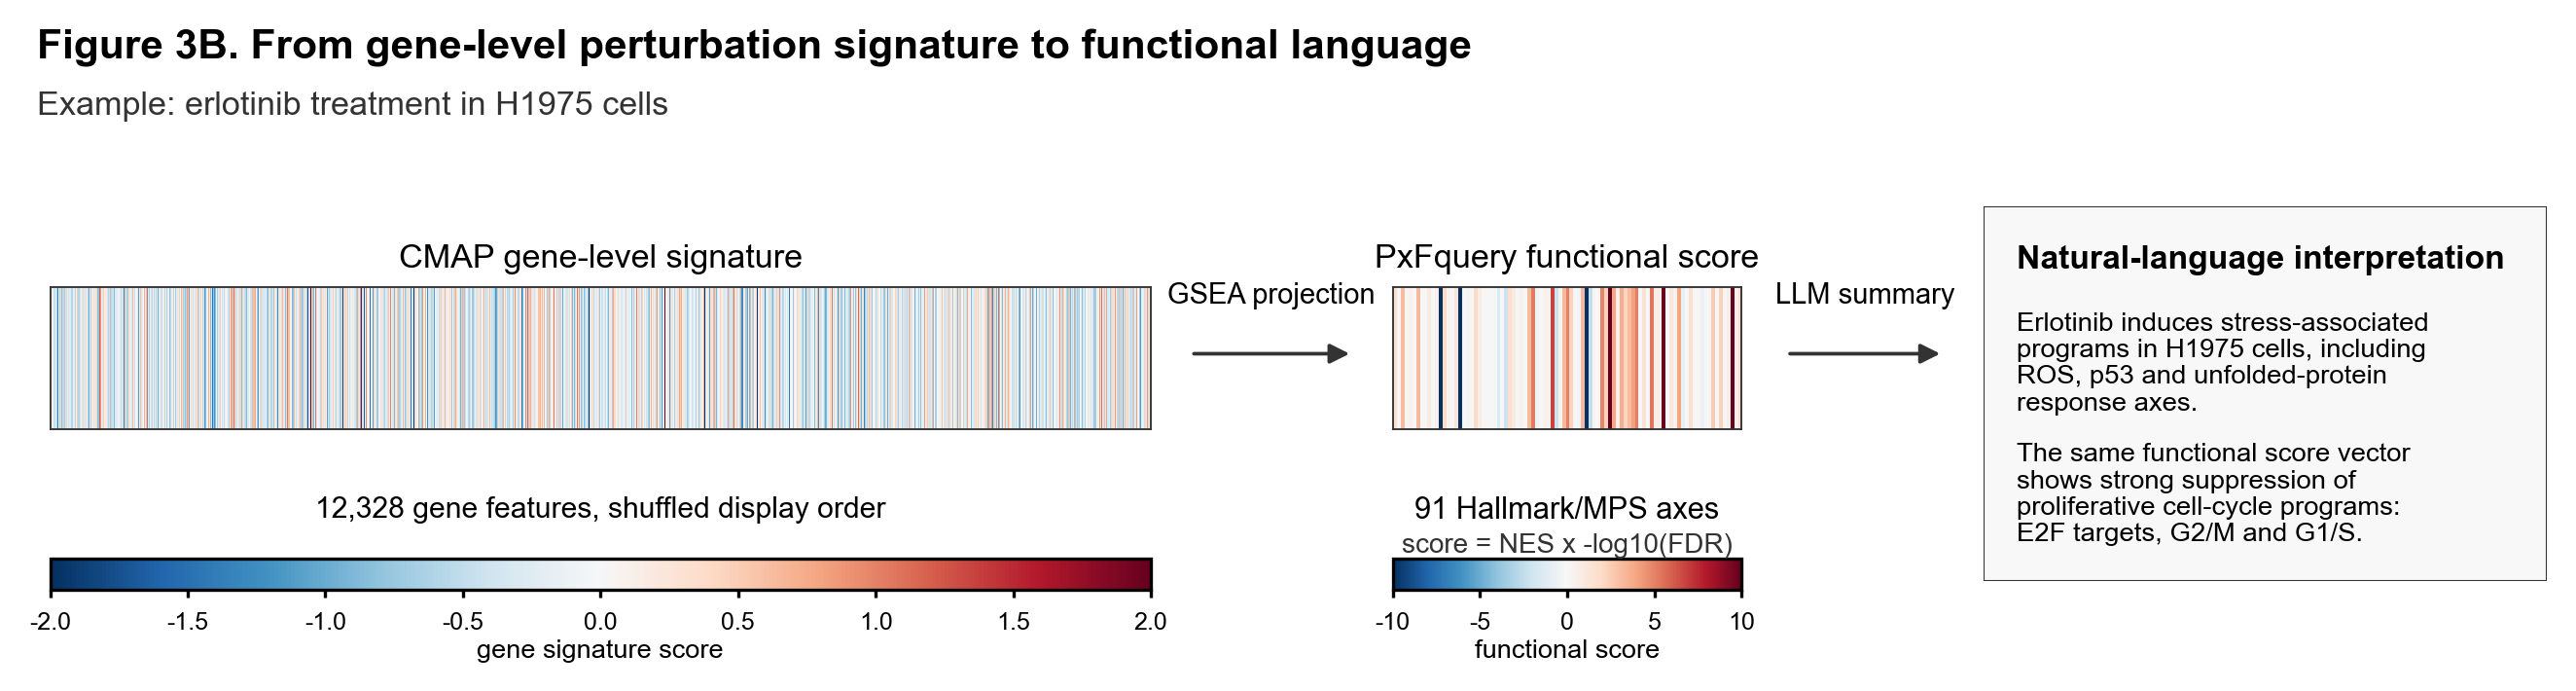

In [3]:
# Figure 3B: real example of representation conversion.
raw_values = raw_ordered['raw_signature_score'].to_numpy()[None, :]
func_values = func_ordered['functional_score'].to_numpy()[None, :]

fig = plt.figure(figsize=(9.2, 3.05), dpi=300)
fig.text(0.04, 0.94, 'Figure 3B. From gene-level perturbation signature to functional language', fontsize=10.2, weight='bold', ha='left', va='top')
fig.text(0.04, 0.87, 'Example: erlotinib treatment in H1975 cells', fontsize=8.2, ha='left', va='top', color='#333333')

ax_raw = fig.add_axes([0.045, 0.49, 0.41, 0.16])
ax_func = fig.add_axes([0.545, 0.49, 0.13, 0.16])
ax_text = fig.add_axes([0.765, 0.32, 0.21, 0.42])

raw_norm = TwoSlopeNorm(vmin=-2, vcenter=0, vmax=2)
func_norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
raw_im = ax_raw.imshow(raw_values, aspect='auto', cmap='RdBu_r', norm=raw_norm, interpolation='nearest')
func_im = ax_func.imshow(func_values, aspect='auto', cmap='RdBu_r', norm=func_norm, interpolation='nearest')

for ax in [ax_raw, ax_func]:
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.45)
        spine.set_color('#333333')

ax_raw.set_title('CMAP gene-level signature', fontsize=8.2, pad=5)
ax_func.set_title('PxFquery functional score', fontsize=8.2, pad=5)
fig.text(0.250, 0.415, f'{raw.shape[0]:,} gene features, shuffled display order', fontsize=7.2, ha='center', va='top')
fig.text(0.610, 0.415, '91 Hallmark/MPS axes', fontsize=7.4, ha='center', va='top')
fig.text(0.610, 0.374, 'score = NES x -log10(FDR)', fontsize=6.7, ha='center', va='top', color='#333333')

# Arrows and labels.
fig.add_artist(FancyArrowPatch((0.468, 0.575), (0.532, 0.575), transform=fig.transFigure, arrowstyle='-|>', mutation_scale=10, linewidth=0.9, color='#333333'))
fig.add_artist(FancyArrowPatch((0.690, 0.575), (0.752, 0.575), transform=fig.transFigure, arrowstyle='-|>', mutation_scale=10, linewidth=0.9, color='#333333'))
fig.text(0.500, 0.625, 'GSEA projection', fontsize=7.0, ha='center', va='bottom')
fig.text(0.721, 0.625, 'LLM summary', fontsize=7.0, ha='center', va='bottom')

# Compact colorbars.
cax1 = fig.add_axes([0.045, 0.31, 0.41, 0.035])
cb1 = fig.colorbar(raw_im, cax=cax1, orientation='horizontal')
cb1.set_label('gene signature score', fontsize=6.5, labelpad=1)
cb1.ax.tick_params(labelsize=6, length=2)
cax2 = fig.add_axes([0.545, 0.31, 0.13, 0.035])
cb2 = fig.colorbar(func_im, cax=cax2, orientation='horizontal')
cb2.set_label('functional score', fontsize=6.5, labelpad=1)
cb2.ax.tick_params(labelsize=6, length=2)

# Natural-language panel from the real top positive/negative functional scores.
ax_text.axis('off')
ax_text.add_patch(Rectangle((0, 0), 1, 1, transform=ax_text.transAxes, facecolor='#f8f8f8', edgecolor='#333333', linewidth=0.5))
ax_text.text(0.06, 0.90, 'Natural-language interpretation', fontsize=8.1, weight='bold', ha='left', va='top')
ax_text.text(
    0.06, 0.72,
    'Erlotinib induces stress-associated\nprograms in H1975 cells, including\nROS, p53 and unfolded-protein\nresponse axes.',
    fontsize=6.6, ha='left', va='top', linespacing=1.18,
)
ax_text.text(
    0.06, 0.37,
    'The same functional score vector\nshows strong suppression of\nproliferative cell-cycle programs:\nE2F targets, G2/M and G1/S.',
    fontsize=6.6, ha='left', va='top', linespacing=1.18,
)

for ext in ['pdf', 'svg', 'png']:
    fig.savefig(FIG_DIR / f'figure3_panelB_signature_to_language.{ext}', bbox_inches='tight')
plt.show()






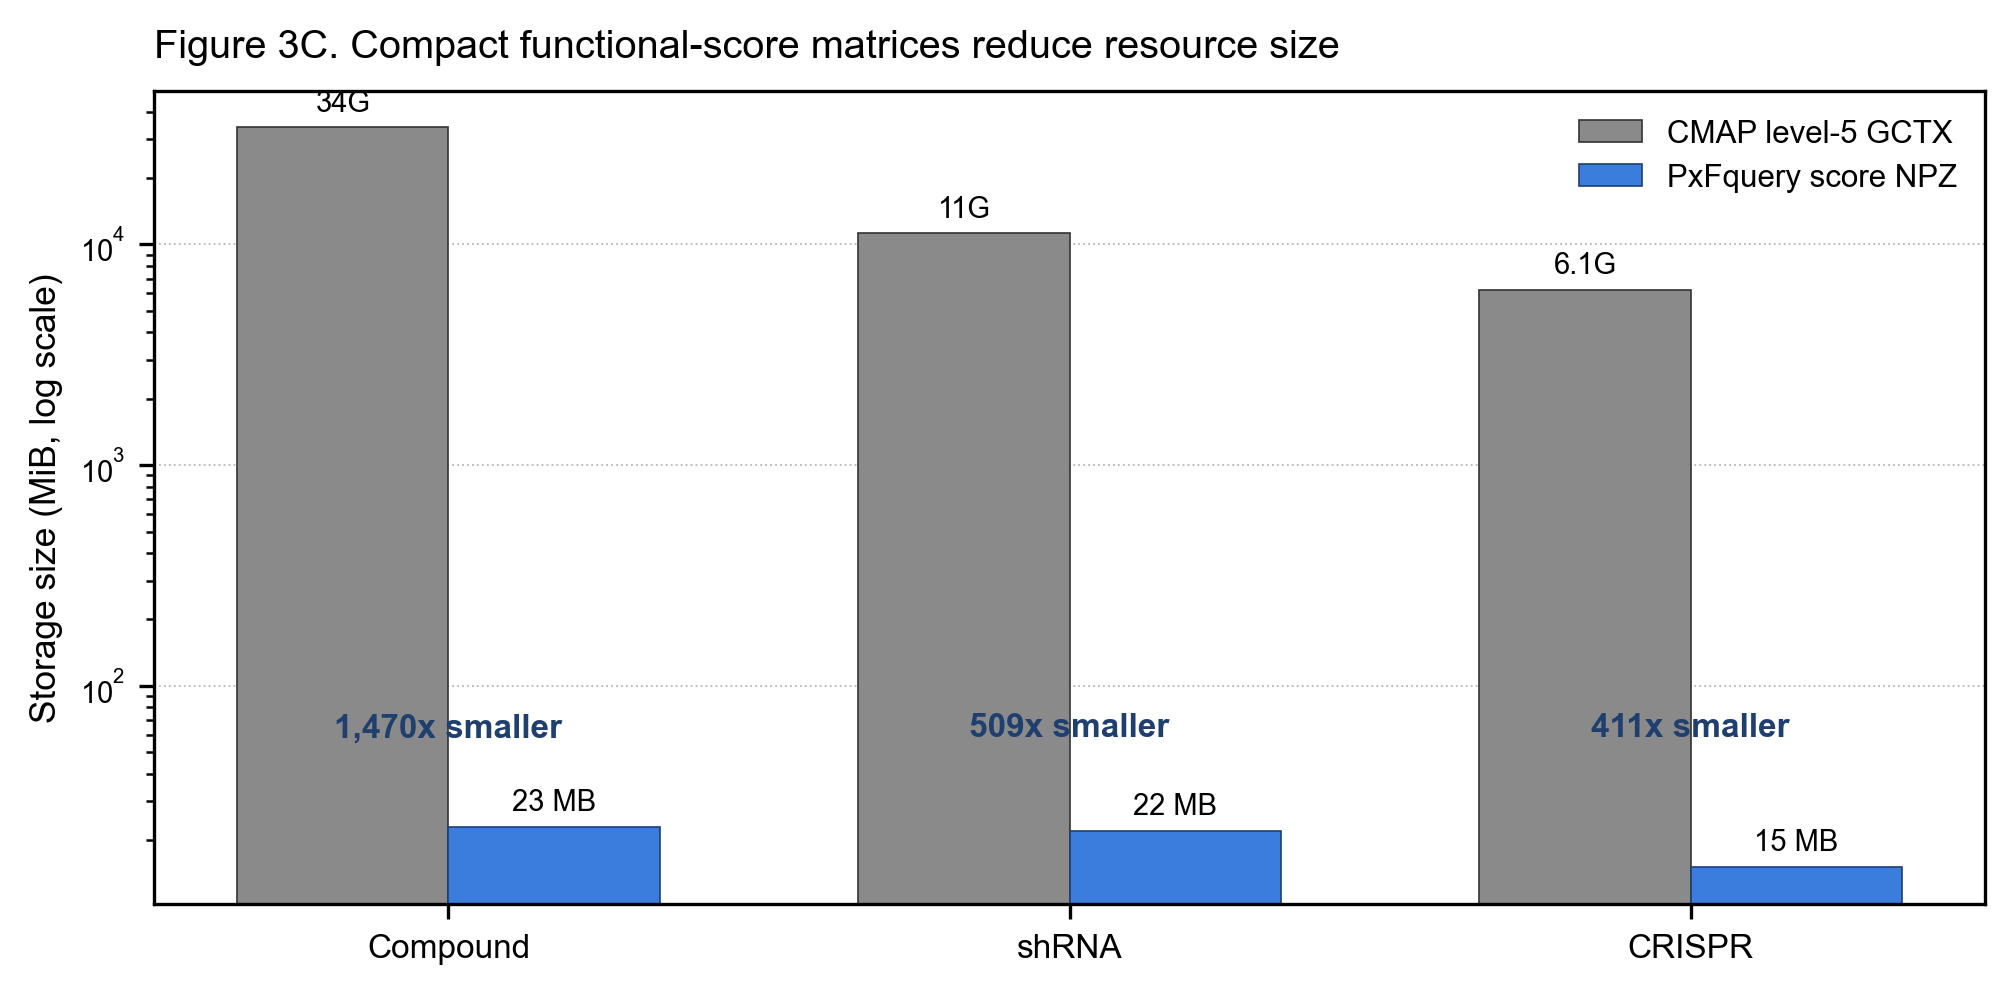

,modality,source,bytes,label,MiB
0,Compound,CMAP level-5 GCTX,35518405386,34G,33872.990976
1,shRNA,CMAP level-5 GCTX,11754477623,11G,11209.943412
2,CRISPR,CMAP level-5 GCTX,6516812529,6.1G,6214.916734
3,Compound,PxFquery score NPZ,24158097,23 MB,23.038957
4,shRNA,PxFquery score NPZ,23082570,22 MB,22.013254
5,CRISPR,PxFquery score NPZ,15863651,15 MB,15.128757


In [4]:
# Figure 3C: storage reduction from raw CMAP GCTX to PxFquery functional-score NPZ.
storage = pd.DataFrame([
    {'modality': 'Compound', 'source': 'CMAP level-5 GCTX', 'bytes': 35518405386, 'label': '34G'},
    {'modality': 'shRNA', 'source': 'CMAP level-5 GCTX', 'bytes': 11754477623, 'label': '11G'},
    {'modality': 'CRISPR', 'source': 'CMAP level-5 GCTX', 'bytes': 6516812529, 'label': '6.1G'},
    {'modality': 'Compound', 'source': 'PxFquery score NPZ', 'bytes': 24158097, 'label': '23 MB'},
    {'modality': 'shRNA', 'source': 'PxFquery score NPZ', 'bytes': 23082570, 'label': '22 MB'},
    {'modality': 'CRISPR', 'source': 'PxFquery score NPZ', 'bytes': 15863651, 'label': '15 MB'},
])
storage['MiB'] = storage['bytes'] / 1024 / 1024
storage.to_csv(TABLE_DIR / 'table_figure3c_storage_comparison.csv', index=False)

modalities = ['Compound', 'shRNA', 'CRISPR']
x = np.arange(len(modalities))
width = 0.34
raw_vals = storage[storage['source'] == 'CMAP level-5 GCTX'].set_index('modality').loc[modalities]
pxf_vals = storage[storage['source'] == 'PxFquery score NPZ'].set_index('modality').loc[modalities]

fig, ax = plt.subplots(figsize=(6.6, 3.2), dpi=300, constrained_layout=True)
b1 = ax.bar(x - width/2, raw_vals['MiB'], width, label='CMAP level-5 GCTX', color='#8a8a8a', edgecolor='#333333', linewidth=0.4)
b2 = ax.bar(x + width/2, pxf_vals['MiB'], width, label='PxFquery score NPZ', color='#3b7ddd', edgecolor='#1f3f6f', linewidth=0.4)
ax.set_yscale('log')
ax.set_ylabel('Storage size (MiB, log scale)', fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(modalities, fontsize=8)
ax.tick_params(axis='y', labelsize=7)
ax.legend(frameon=False, fontsize=7.5, loc='upper right')
ax.set_title('Figure 3C. Compact functional-score matrices reduce resource size', fontsize=9.5, loc='left', pad=8)
ax.grid(axis='y', which='major', linestyle=':', linewidth=0.45, color='#bbbbbb')
ax.set_axisbelow(True)
for bars, labels in [(b1, raw_vals['label']), (b2, pxf_vals['label'])]:
    for bar, label in zip(bars, labels):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.12, label, ha='center', va='bottom', fontsize=7)

for i, modality in enumerate(modalities):
    ratio = raw_vals.loc[modality, 'bytes'] / pxf_vals.loc[modality, 'bytes']
    ax.text(
        x[i],
        55,
        f'{ratio:,.0f}x smaller',
        ha='center',
        va='bottom',
        fontsize=8,
        color='#1f3f6f',
        weight='bold',
    )
for ext in ['pdf', 'svg', 'png']:
    fig.savefig(FIG_DIR / f'figure3_panelC_storage_comparison.{ext}', bbox_inches='tight')
plt.show()
storage


